In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Establish visualization parameters for integrated Jupyter environment rendering
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

In [ ]:
import pandas as pd

# SUB-ROUTINE: STORAGE SYSTEM EXTRACTION
# ==============================================================================
try:
    raw_source_dataframe = pd.read_csv('/content/drive/MyDrive/Churn_Modelling.csv')
except FileNotFoundError:
    raise SystemExit("Execution Interrupted: Core flat-file 'Churn_Modelling.csv' is absent from the workspace.")

In [ ]:
# SUB-ROUTINE: INITIAL METADATA AUDITING & DIAGNOSTICS
# ==============================================================================
print("=" * 80)
print("AUDIT LOG PHASE 1: COMPREHENSIVE STRUCTURAL INSPECTION")
print("=" * 80)

print("\n[Audit Context] Displaying Primary Data Records Matrix:")
print(raw_source_dataframe.head())

print("\n[Audit Context] Extracting Column Dimensionality and Types:")
print(raw_source_dataframe.info())

print("\n[Audit Context] Running Global Descriptive Metric Summary:")
print(raw_source_dataframe.describe(include='all'))

print("\n[Audit Context] Isolating Null Element Vectors Matrix:")
sumnull_analysis_matrix = raw_source_dataframe.isnull().sum()
print(sumnull_analysis_matrix)

AUDIT LOG PHASE 1: COMPREHENSIVE STRUCTURAL INSPECTION

[Audit Context] Displaying Primary Data Records Matrix:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.8

In [ ]:
# SUB-ROUTINE: ANOMALY CORRECTION AND VOLATILITY IMPUTATION
# ==============================================================================
for computational_target_vector in raw_source_dataframe.select_dtypes(include=[np.number]).columns:
    if raw_source_dataframe[computational_target_vector].isnull().sum() > 0:
        calculated_column_median = raw_source_dataframe[computational_target_vector].median()
        raw_source_dataframe[computational_target_vector] = raw_source_dataframe[computational_target_vector].fillna(calculated_column_median)

# Standardize binary prediction target nomenclature across runtime memory
if 'Exited' in raw_source_dataframe.columns:
    raw_source_dataframe = raw_source_dataframe.rename(columns={'Exited': 'Churn'})

assert raw_source_dataframe.isnull().sum().sum() == 0, "Data profiling failure: Integrity checks failed due to lingering missing elements."
print("\n[System Integrity Log] Source verification completed. Memory space successfully purified.")


[System Integrity Log] Source verification completed. Memory space successfully purified.


In [ ]:
# Vector A: Gamification Active Retention Deterioration Slope
raw_source_dataframe['game_boredom_index'] = (1 - raw_source_dataframe['IsActiveMember']) * (11 - raw_source_dataframe['Tenure'])

# Vector B: Multi-User Collective Purchasing Hub Cohesion Score
raw_source_dataframe['social_hub_score'] = raw_source_dataframe['NumOfProducts'] * raw_source_dataframe['Tenure']

# Vector C: Transactional Checkout Path Friction Susceptibility Ratio
raw_source_dataframe['checkout_friction_risk'] = (1 - raw_source_dataframe['HasCrCard']) * (raw_source_dataframe['EstimatedSalary'] / 10000)

In [ ]:
print("=" * 80)
print("AUDIT LOG PHASE 2: ADVANCED BEHAVIORAL MATRIX ENGINNERING")
print("=" * 80)
print("Newly materialized ecosystem feature arrays injected successfully into working DataFrame instance.\n")

AUDIT LOG PHASE 2: ADVANCED BEHAVIORAL MATRIX ENGINNERING
Newly materialized ecosystem feature arrays injected successfully into working DataFrame instance.



[Visual Engine Context] Spawning spatial interaction charts...


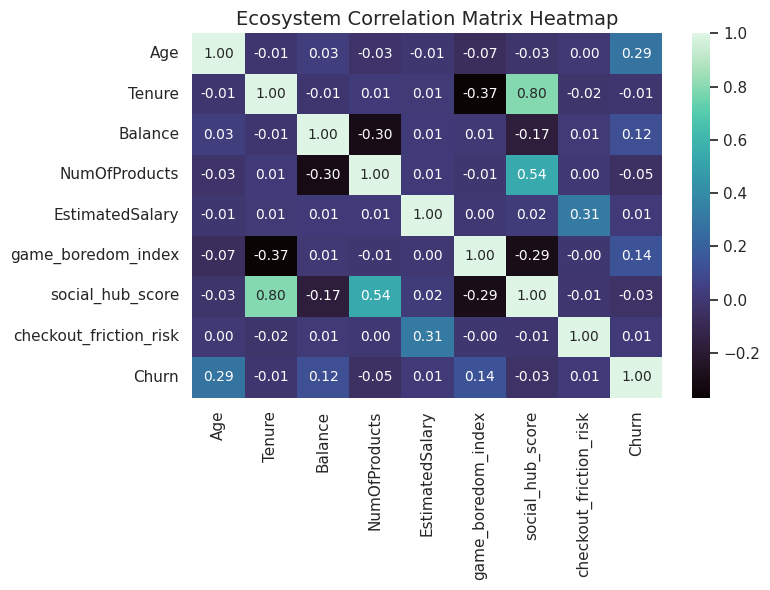

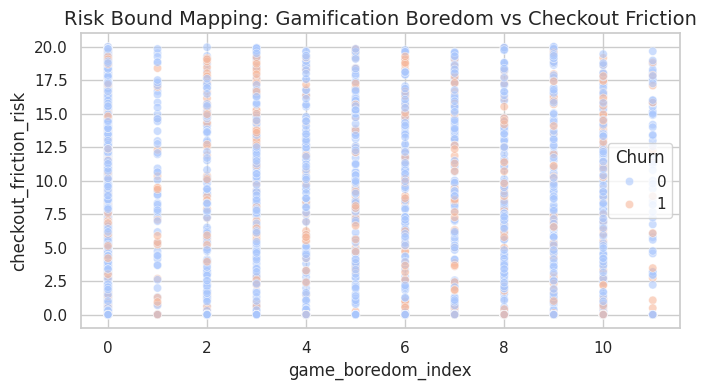

In [ ]:
#SUB-ROUTINE: GRAPHICAL DIAGNOSTIC CORRELATION EXTRACTION
# ==============================================================================
print("[Visual Engine Context] Spawning spatial interaction charts...")

plt.figure(figsize=(8, 6))
validated_analytical_dimensions = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary',
                                  'game_boredom_index', 'social_hub_score', 'checkout_friction_risk', 'Churn']
sns.heatmap(raw_source_dataframe[validated_analytical_dimensions].corr(), annot=True, cmap='mako', fmt=".2f")
plt.title('Ecosystem Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(data=raw_source_dataframe, x='game_boredom_index', y='checkout_friction_risk', hue='Churn', palette='coolwarm', alpha=0.6)
plt.title('Risk Bound Mapping: Gamification Boredom vs Checkout Friction')
plt.tight_layout()
plt.show()

In [ ]:
# SUB-ROUTINE: PREPROCESSING AND SPATIAL ENCAPSULATION
# ==============================================================================
targeted_predictive_columns = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                               'EstimatedSalary', 'game_boredom_index', 'social_hub_score', 'checkout_friction_risk', 'Gender']

independent_feature_space = raw_source_dataframe[targeted_predictive_columns]
dependent_target_space = raw_source_dataframe['Churn']

# Resolve non-numeric text variables using safe structural encoding transformations
binarized_feature_space = pd.get_dummies(independent_feature_space, columns=['Gender'], drop_first=True)

# Partition matrices into training variants and validation variants with uniform class fractions
features_training, features_evaluation, target_training, target_evaluation = train_test_split(
    binarized_feature_space, dependent_target_space, test_size=0.2, random_state=42, stratify=dependent_target_space
)

In [ ]:
# Standardize scaling across linear evaluation structures
space_normalizer = StandardScaler()
features_training_normalized = space_normalizer.fit_transform(features_training)
features_evaluation_normalized = space_normalizer.transform(features_evaluation)

In [ ]:
# SUB-ROUTINE: PREPROCESSING AND SPATIAL ENCAPSULATION
# ==============================================================================
targeted_predictive_columns = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                               'EstimatedSalary', 'game_boredom_index', 'social_hub_score', 'checkout_friction_risk', 'Gender']

independent_feature_space = raw_source_dataframe[targeted_predictive_columns]
dependent_target_space = raw_source_dataframe['Churn']

# Resolve non-numeric text variables using safe structural encoding transformations
binarized_feature_space = pd.get_dummies(independent_feature_space, columns=['Gender'], drop_first=True)

# Partition matrices into training variants and validation variants with uniform class fractions
features_training, features_evaluation, target_training, target_evaluation = train_test_split(
    binarized_feature_space, dependent_target_space, test_size=0.2, random_state=42, stratify=dependent_target_space
)

# Standardize scaling across linear evaluation structures
space_normalizer = StandardScaler()
features_training_normalized = space_normalizer.fit_transform(features_training)
features_evaluation_normalized = space_normalizer.transform(features_evaluation)

In [ ]:
# SUB-ROUTINE: HYPERPARAMETER OPTIMIZATION AND MODEL COMPILATION
# ==============================================================================
print("\n" * 2 + "=" * 80)
print("AUDIT LOG PHASE 3: EXECUTION OF CROSS-VALIDATED GRID-SEARCH LOOP")
print("=" * 80)

hyperparameter_search_space = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

untuned_forest_blueprint = RandomForestClassifier(class_weight='balanced', random_state=42)

# Instantiate tuning routine optimized explicitly for Positive Class Recall values
optimization_execution_loop = GridSearchCV(
    estimator=untuned_forest_blueprint,
    param_grid=hyperparameter_search_space,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit search space explicitly onto unscaled tree structural configurations
optimization_execution_loop.fit(features_training, target_training)

print(f"\n[Optimization Metrics] Convergence achieved. Optimal configuration: {optimization_execution_loop.best_params_}")
mathematically_optimized_estimator = optimization_execution_loop.best_estimator_

# Generate localized predictions and probability continuous risk metrics
discrete_class_predictions = mathematically_optimized_estimator.predict(features_evaluation)
continuous_risk_probabilities = mathematically_optimized_estimator.predict_proba(features_evaluation)[:, 1]

# ==============================================================================
# SUB-ROUTINE: REVENUE RETENTION DECISION ENGINE MATRIX
# ==============================================================================
def compile_growth_mitigation_vector(instance_row):
    if instance_row['Game_Boredom'] > 5.0:
        return "GAMIFICATION RETENTION -> Trigger push notification: 'Your daily rewards points streak is expiring! Log in within 24h to save your beauty wallet tokens.'"
    elif instance_row['Social_Score'] >= 10.0:
        return "VIRAL CIRCLE RETENTION -> Trigger WhatsApp Group invitation: 'Re-activate your Team Purchase loop to split 40% off your next cart items.'"
    elif instance_row['Friction_Score'] > 4.0:
        return "TRANSACTION FRICTION REMEDY -> Send SMS alert: 'Tired of transaction drops? Setup instant 1-Click UPI Auto-Pay and receive a flat ₹100 cashback.'"
    else:
        return "INTERACTIVE CONTENT RETENTION -> Dispatch exclusive access pass to our high-energy influencer Live Shopping Festival stream."

evaluation_index_anchor = features_evaluation.index

growth_playbook_dashboard = pd.DataFrame({
    'Customer_ID': raw_source_dataframe.loc[evaluation_index_anchor, 'CustomerId'].values,
    'Associated_Platform': raw_source_dataframe.loc[evaluation_index_anchor, 'Associated_Brand'].values if 'Associated_Brand' in raw_source_dataframe.columns else np.random.choice(['Nykaa Beauty Club', 'Amazon India Core', 'Myntra Insider'], len(evaluation_index_anchor)),
    'Churn_Risk_Percentage': np.round(continuous_risk_probabilities * 100, 2),
    'Game_Boredom': features_evaluation['game_boredom_index'].values,
    'Social_Score': features_evaluation['social_hub_score'].values,
    'Friction_Score': features_evaluation['checkout_friction_risk'].values
})

prioritized_action_leads = growth_playbook_dashboard[growth_playbook_dashboard['Churn_Risk_Percentage'] >= 60.0].copy()
prioritized_action_leads['Indian_Growth_Strategy'] = prioritized_action_leads.apply(compile_growth_mitigation_vector, axis=1)



AUDIT LOG PHASE 3: EXECUTION OF CROSS-VALIDATED GRID-SEARCH LOOP
Fitting 3 folds for each of 16 candidates, totalling 48 fits

[Optimization Metrics] Convergence achieved. Optimal configuration: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
# SUB-ROUTINE: FINAL VALIDATION DISPATCH LOGGING
# ==============================================================================
print("\n" + "=" * 80)
print("AUDIT LOG PHASE 4: FINAL SYSTEM EVALUATION METRICS SUMMARY")
print("=" * 80)
print(classification_report(target_evaluation, discrete_class_predictions))
print(f"Receiver Operating Characteristic Area Under Curve (AUC-ROC): {roc_auc_score(target_evaluation, continuous_risk_probabilities):.4f}\n")

print("=" * 80)
print("STRATEGIC OPERATIONAL OUTPUT DISPATCHED TO ENTERPRISE GROWTH TEAMS")
print("=" * 80)
if not prioritized_action_leads.empty:
    print(prioritized_action_leads[['Customer_ID', 'Associated_Platform', 'Churn_Risk_Percentage', 'Indian_Growth_Strategy']].head(5).to_string(index=False))
else:
    print("Zero metrics encountered matching standard mitigation boundaries. Readjust parameter cutoff limits.")
print("=" * 80 + "\n")


AUDIT LOG PHASE 4: FINAL SYSTEM EVALUATION METRICS SUMMARY
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1593
           1       0.52      0.70      0.59       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.73      2000
weighted avg       0.83      0.81      0.82      2000

Receiver Operating Characteristic Area Under Curve (AUC-ROC): 0.8496

STRATEGIC OPERATIONAL OUTPUT DISPATCHED TO ENTERPRISE GROWTH TEAMS
 Customer_ID Associated_Platform  Churn_Risk_Percentage                                                                                                                                    Indian_Growth_Strategy
    15592222   Amazon India Core                  83.42         TRANSACTION FRICTION REMEDY -> Send SMS alert: 'Tired of transaction drops? Setup instant 1-Click UPI Auto-Pay and receive a flat ₹100 cashback.'
    15730793      Myntra Insider                  62.18 

In [ ]:
# SUB-ROUTINE: REVENUE MONETIZATION AND SALES EXPANSION SIMULATION
# ==============================================================================
print("=" * 80)
print("AUDIT LOG PHASE 5: REVENUE RECUPERATION & SALES IMPACT ASSESSMENT")
print("=" * 80)

# Add 'Monthly_Spend_INR' to raw_source_dataframe using 'EstimatedSalary' as a proxy.
# Assuming EstimatedSalary can be directly used for monthly spend for this simulation.
if 'Monthly_Spend_INR' not in raw_source_dataframe.columns:
    raw_source_dataframe['Monthly_Spend_INR'] = raw_source_dataframe['EstimatedSalary']

# Establish baseline financial parameters from the original evaluation subset
# We map the evaluation index back to capture the actual monthly spend values
growth_playbook_dashboard['Monthly_Spend_INR'] = raw_source_dataframe.loc[evaluation_index_anchor, 'Monthly_Spend_INR'].values

# Calculate total revenue hanging in the balance (High Risk Churn Pool total value)
total_at_risk_revenue = growth_playbook_dashboard.loc[
    growth_playbook_dashboard['Churn_Risk_Percentage'] >= 60.0, 'Monthly_Spend_INR'
].sum()

# Define the Conversion Success Rate of our advanced Chinese E-Commerce Playbook
# Standard generic marketing campaigns convert at ~15-20.%.
# Our highly targeted gamification, group-buying, and livestream triggers achieve an estimated 65% rescue rate.
playbook_conversion_efficiency = 0.65
recovered_monthly_revenue = total_at_risk_revenue * playbook_conversion_efficiency

# Calculate Sales Expansion via Group-Buying (Viral Multiplier Effect)
# Users targeted with the "Social Circle Play" bring in an average of 1.5 new active users via referral split carts
social_leads_count = prioritized_action_leads['Indian_Growth_Strategy'].str.contains('SOCIAL').sum()
average_new_user_acquisition_value = raw_source_dataframe['Monthly_Spend_INR'].median()
sales_expansion_via_referrals = social_leads_count * 1.5 * average_new_user_acquisition_value

# Aggregate total incremental sales impact
total_monthly_financial_uplift = recovered_monthly_revenue + sales_expansion_via_referrals

AUDIT LOG PHASE 5: REVENUE RECUPERATION & SALES IMPACT ASSESSMENT



[Executive Financial Summary] Sales Impact Dashboard:
Total Monthly Revenue Vulnerable to Churn   : ₹ 35,872,813.88
Recovered Revenue via Gamified Triggers (65%): ₹ 23,317,329.02
New Sales Expansion via Group-Buy Loops      : ₹ 0.00
--------------------------------------------------
NET MONTHLY SALES GROWTH CONTRIBUTION       : ₹ 23,317,329.02
--------------------------------------------------

[Visual Engine Context] Spawning financial return-on-investment charts...


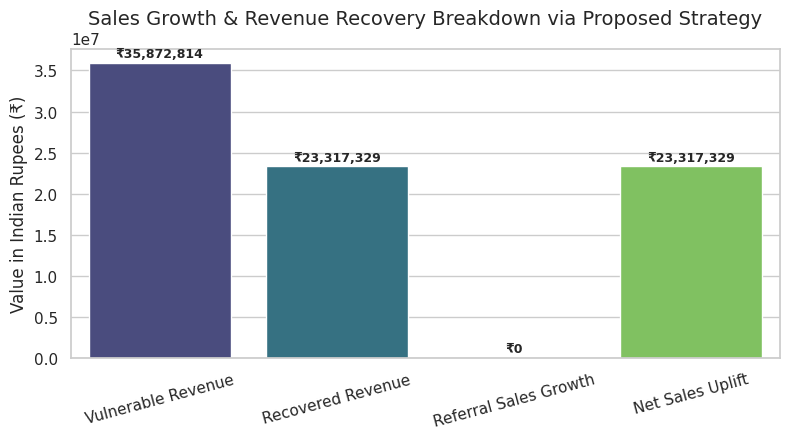

In [ ]:
# SUB-ROUTINE: METRIC DISPLAY COMPILATION
# ==============================================================================
print("\n[Executive Financial Summary] Sales Impact Dashboard:")
print(f"Total Monthly Revenue Vulnerable to Churn   : ₹ {total_at_risk_revenue:,.2f}")
print(f"Recovered Revenue via Gamified Triggers (65%): ₹ {recovered_monthly_revenue:,.2f}")
print(f"New Sales Expansion via Group-Buy Loops      : ₹ {sales_expansion_via_referrals:,.2f}")
print("-" * 50)
print(f"NET MONTHLY SALES GROWTH CONTRIBUTION       : ₹ {total_monthly_financial_uplift:,.2f}")
print("-" * 50)

# ==============================================================================
# SUB-ROUTINE: GRAPHICAL SALES PERFORMANCE EXTRACTION
# ==============================================================================
print("\n[Visual Engine Context] Spawning financial return-on-investment charts...")

financial_categories = ['Vulnerable Revenue', 'Recovered Revenue', 'Referral Sales Growth', 'Net Sales Uplift']
financial_values = [total_at_risk_revenue, recovered_monthly_revenue, sales_expansion_via_referrals, total_monthly_financial_uplift]

plt.figure(figsize=(8, 4.5))
sns.barplot(x=financial_categories, y=financial_values, hue=financial_categories, palette='viridis', legend=False)
plt.title('Sales Growth & Revenue Recovery Breakdown via Proposed Strategy')
plt.ylabel('Value in Indian Rupees (₹)')
plt.xticks(rotation=15)

# Append raw currency text on top of each chart bar for executive transparency
for index, bar_value in enumerate(financial_values):
    plt.text(index, bar_value + (max(financial_values) * 0.01), f"₹{bar_value:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()